In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
# import path
from pathlib import Path
root = Path.cwd().parent

DATA_DIR = root/'Dataset'
OUTPUT_DIR = root/'Results'

In [3]:
df = pd.read_csv(DATA_DIR/'Geo_lith_landuse.csv', header=0)

# Geology & Land-Use Comparability of Control Samples (Group C) vs. Non-Extra Groups

In [4]:
GROUP_MEMBERS_GEO = {
    'C':  ['C'],
    'HS': ['HS', 'HS/I', 'HS/S'],
    'I':  ['I',  'HS/I'],
    'S':  ['S',  'HS/S'],
}
CAT_COLS = ['geology unit name', 'major lithologic component', 'land use']

df_nonextra = df[df['Sample Group'] != 'Extra'].copy()

def _subset(g):
    return df_nonextra[df_nonextra['Sample Group'].isin(GROUP_MEMBERS_GEO[g])]

def _collapse_rare(ct, min_count=2):
    """Merge columns with fewer than min_count total observations into 'Other'."""
    keep = ct.sum(axis=0) >= min_count
    result = ct.loc[:, keep].copy()
    other_sum = ct.loc[:, ~keep].sum(axis=1)
    if other_sum.sum() > 0:
        result['Other'] = other_sum
    return result

def _test(ct):
    """Fisher's exact (2×2) or chi-square with expected-count check (R×C)."""
    if ct.shape == (2, 2):
        _, p = stats.fisher_exact(ct.values)
        return p, "Fisher's exact"
    chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
    low_cells = (expected < 5).sum()
    note = f" [!{low_cells} cells expected<5]" if low_cells else ""
    return p, f"chi-square{note}"

ctrl_df = _subset('C')

for col in CAT_COLS:
    print(f"\n{'='*60}")
    print(f"  {col}")
    print('='*60)
    for other in ['HS', 'I', 'S']:
        other_df = _subset(other)
        ct = pd.crosstab(
            pd.Series(['C']*len(ctrl_df) + [other]*len(other_df), name='Group'),
            pd.concat([ctrl_df[col].fillna('Unknown'),
                       other_df[col].fillna('Unknown')]).reset_index(drop=True),
        )
        ct = _collapse_rare(ct, min_count=2)
        p, method = _test(ct)
        sig = " *" if p < 0.05 else ""
        print(f"\nC (n={len(ctrl_df)}) vs {other} (n={len(other_df)})  —  {method},  p = {p:.4f}{sig}")
        # show % within each group
        pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
        display_df = ct.astype(str) + "  (" + pct.astype(str) + "%)"
        print(display_df.to_string())
print("\n* p < 0.05 (not comparable)")


  geology unit name

C (n=8) vs HS (n=30)  —  chi-square [!16 cells expected<5],  p = 0.0544
geology unit name Anorthosite Banded mafic gneiss Greene Formation Greenstone schist Metarhyolite Monongahela Group Washington Formation Waynesburg Formation       Other
Group                                                                                                                                                                    
C                  2  (25.0%)          1  (12.5%)        0  (0.0%)         0  (0.0%)   1  (12.5%)         0  (0.0%)           3  (37.5%)           1  (12.5%)   0  (0.0%)
HS                  0  (0.0%)           1  (3.3%)       4  (13.3%)        3  (10.0%)    2  (6.7%)         2  (6.7%)           4  (13.3%)           9  (30.0%)  5  (16.7%)

C (n=8) vs I (n=24)  —  chi-square [!13 cells expected<5],  p = 0.0097 *
geology unit name Anorthosite Greene Formation Greenstone schist Metarhyolite Washington Formation Waynesburg Formation       Other
Group               

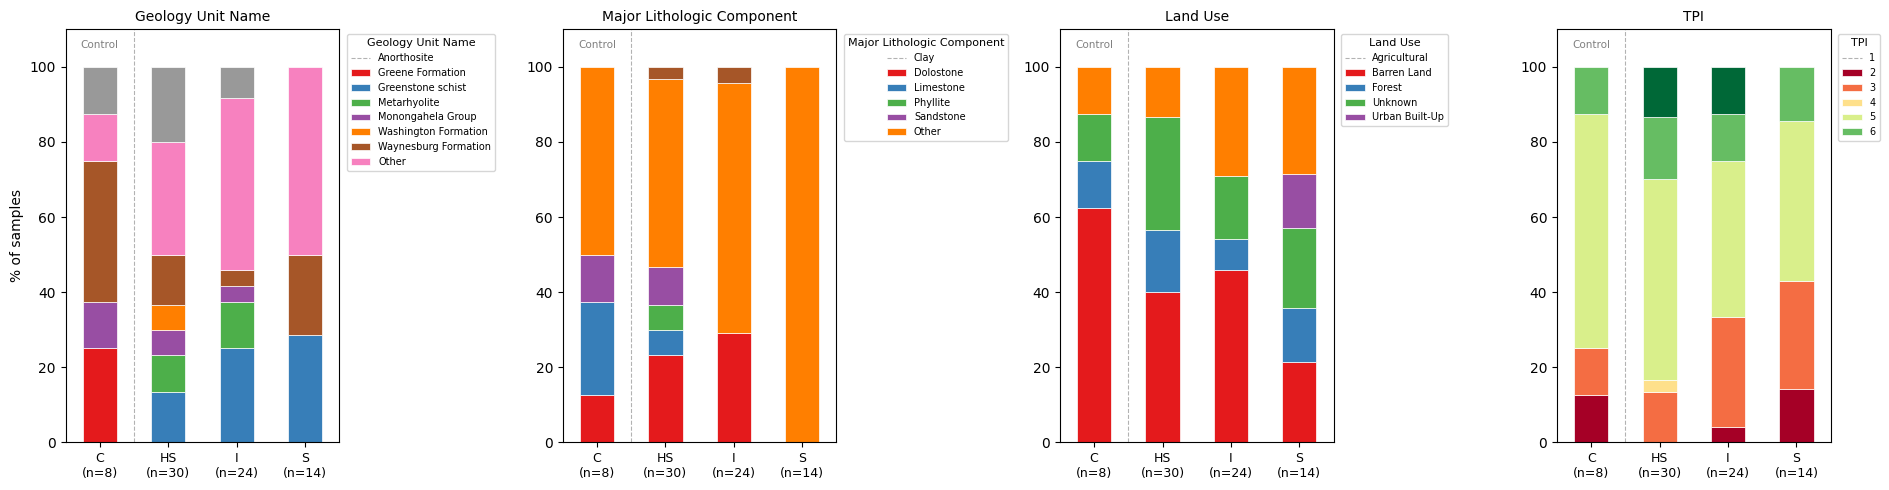

In [5]:
GROUP_ORDER_GEO = ['C', 'HS', 'I', 'S']
PALETTE = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf','#999999']

# tpi is discrete integers — treat each value as an ordered category
df_nonextra['tpi_cat'] = (df_nonextra['tpi']
                          .dropna()
                          .astype(int)
                          .astype(str)
                          .reindex(df_nonextra.index))

CAT_COLS_PLOT = ['geology unit name', 'major lithologic component', 'land use', 'tpi_cat']
COL_TITLES    = ['Geology Unit Name', 'Major Lithologic Component', 'Land Use', 'TPI']

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
# fig.suptitle('Category Distribution by Sample Group\n'
#              '(HS/I → HS & I;  HS/S → HS & S)', fontsize=12)

for ax, col, title in zip(axes, CAT_COLS_PLOT, COL_TITLES):
    rows = {}
    for g in GROUP_ORDER_GEO:
        sub = _subset(g)[col].fillna('Unknown')
        rows[g] = sub.value_counts()
    pct_df = pd.DataFrame(rows).T.fillna(0)

    if col == 'tpi_cat':
        # keep all integer levels in sorted order; no rare-collapse needed
        int_cols = sorted([c for c in pct_df.columns if c != 'Unknown'],
                          key=lambda x: int(x))
        other_cols = [c for c in pct_df.columns if c not in int_cols]
        pct_df = pct_df[int_cols + other_cols]
        tpi_palette = plt.cm.RdYlGn(
            [i / max(len(int_cols) - 1, 1) for i in range(len(int_cols))])
        colors = list(tpi_palette) + ['#999999'] * len(other_cols)
    else:
        # collapse rare categories into 'Other'
        threshold = 0.05 * pct_df.values.sum(axis=1).max()
        major     = pct_df.columns[pct_df.max(axis=0) >= threshold]
        minor     = pct_df.columns[pct_df.max(axis=0) < threshold]
        other_sum = pct_df[minor].sum(axis=1)
        pct_df    = pct_df[major].copy()
        if other_sum.sum() > 0:
            pct_df['Other'] = other_sum
        colors = PALETTE[:len(pct_df.columns)]

    pct_pct = pct_df.div(pct_df.sum(axis=1), axis=0).mul(100)

    pct_pct.plot(kind='bar', stacked=True, ax=ax, color=colors,
                 edgecolor='white', linewidth=0.5, legend=False)

    ax.set_title(title, fontsize=10)
    ax.set_ylabel('% of samples' if ax == axes[0] else '')
    ax.set_ylim(0, 110)
    ax.set_xticklabels(
        [f"{g}\n(n={len(_subset(g))})" for g in GROUP_ORDER_GEO],
        rotation=0, fontsize=9)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(0, 105, 'Control', ha='center', fontsize=7.5, color='grey')
    ax.legend(pct_pct.columns, bbox_to_anchor=(1.01, 1), loc='upper left',
            fontsize=7, title=title, title_fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Figures', 'Fig_S7_2024_swpa_categorical_comparison.pdf'), bbox_inches='tight')
plt.show()